In [2]:
import numpy as np 
import pandas as pd

In [3]:
import seaborn as sb
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("datasets\minute maid_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",NaN,NaN,NaN,c,4.0,NaN,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,NaN,NaN,NaN,e,NaN,NaN,NaN,NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,NaN,NaN,NaN,unknown,NaN,c,NaN,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,NaN,NaN,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,NaN,NaN,NaN,e,4.0,NaN,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,01070965,Minute maid,NaN,NaN,france,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
681,6975682483042,MZY Peach Juice Drink,"Minute Maid, Coca-Cola, MZY","beverages-and-beverages-preparations, plant-ba...","china, united-kingdom",NaN,NaN,NaN,e,4.0,NaN,"Water, fructose syrup, sugar, concentrated pea...",NaN,NaN
682,9416216001433,Minute Maid Pulpy,Orange,NaN,fiji,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
683,4902102060646,Apple 100%,Minute Maid,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


In [5]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

In [6]:
df.dtypes

code                            object
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [7]:
df.code[df.duplicated()]

Series([], Name: code, dtype: object)

In [8]:
df.isnull().sum()

code                             0
product_name                    10
brands                          51
categories_tags                256
countries_tags                   0
packaging_tags                 618
stores                         659
purchase_places                646
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                 542
ingredients_text               294
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

In [9]:
df.product_name = df.product_name.fillna('unknown')
df.brands = df.brands.fillna('unknown')
df.categories_tags = df.categories_tags.fillna('unknown')
df.packaging_tags = df.packaging_tags.fillna('unknown')
df.stores = df.stores.fillna('unknown')
df.purchase_places = df.purchase_places.fillna('unknown')
df.ecoscore_grade = df.ecoscore_grade.fillna('unknown')
df.ingredients_text = df.ingredients_text.fillna('unknown')


In [10]:
df.isnull().sum()

code                             0
product_name                     0
brands                           0
categories_tags                  0
countries_tags                   0
packaging_tags                   0
stores                           0
purchase_places                  0
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                   0
ingredients_text                 0
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

# Extracting Countries

In [11]:
df.countries_tags.unique()

array(['france, united-states', 'france', 'united-states',
       'saint-pierre-and-miquelon', 'canada, france', 'canada',
       'france, martinique, switzerland', 'belgium, france, luxembourg',
       'taiwan', 'hong-kong', 'belgium, france', 'belgium',
       'belgium, france, martinique, switzerland', 'france, spain',
       'belgium, france, world', 'united-kingdom', 'spain', 'thailand',
       'india', 'france, luxembourg', 'belgium, france, germany',
       'belgium, france, switzerland', 'belgium, france, reunion',
       'france, spain, united-states', 'canada, switzerland',
       'martinique', 'switzerland', 'france, world', 'germany',
       'belgium, world', 'singapore', 'france, united-states, world',
       'senegal', 'united-states, world', 'mexico', 'canada, germany',
       'ireland', 'aruba', 'puerto-rico', 'luxembourg', 'kenya',
       'jamaica', 'philippines', 'barbados', 'ethiopia', 'suriname',
       'malaysia', 'mayotte', 'trinidad-and-tobago', 'norway', 'japan'

In [12]:
df.countries_tags.value_counts

<bound method IndexOpsMixin.value_counts of 0      france, united-states
1                     france
2              united-states
3              united-states
4                     france
               ...          
680                   france
681    china, united-kingdom
682                     fiji
683            united-states
684                    japan
Name: countries_tags, Length: 685, dtype: object>

In [13]:
raw_countries = df.countries_tags.str.split(',')
raw_countries

0      [france,  united-states]
1                      [france]
2               [united-states]
3               [united-states]
4                      [france]
                 ...           
680                    [france]
681    [china,  united-kingdom]
682                      [fiji]
683             [united-states]
684                     [japan]
Name: countries_tags, Length: 685, dtype: object

In [14]:
exploded_countries = raw_countries.explode()
exploded_countries

0               france
0        united-states
1               france
2        united-states
3        united-states
            ...       
681              china
681     united-kingdom
682               fiji
683      united-states
684              japan
Name: countries_tags, Length: 757, dtype: object

In [15]:
exploded_countries = exploded_countries.str.strip()
exploded_countries

0              france
0       united-states
1              france
2       united-states
3       united-states
            ...      
681             china
681    united-kingdom
682              fiji
683     united-states
684             japan
Name: countries_tags, Length: 757, dtype: object

In [53]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

In [52]:
exploded_countries.value_counts().sum()

np.int64(757)

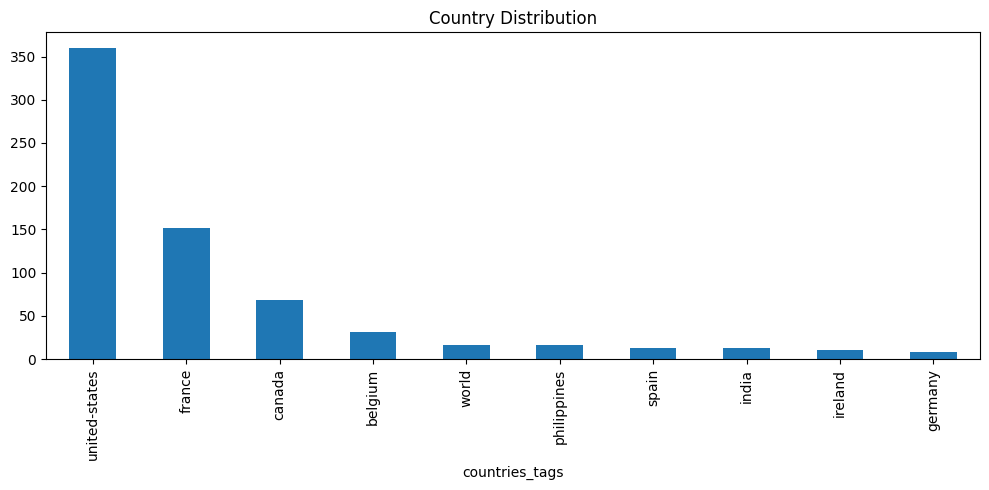

In [17]:
plt.figure(figsize=(10,5))

exploded_countries.value_counts().head(10).plot(kind='bar')

plt.title("Country Distribution")
plt.tight_layout()
plt.show()

# Extracting Packaging

In [18]:
df.packaging_tags.unique()

array(['unknown', 'pet-bottle', 'brick', 'cardboard', 'plastic',
       'box, card, pasteurized', 'can, drink-can', 'cardboard, tumbler',
       'bouteille-verre', 'tetra-pak, tetra-brik-aseptic',
       'plastic, bottle', 'bottle', 'tetra-brik', 'metal, can, drink-can',
       'brick, cardboard', 'can', 'brique',
       'metal, recyclable-metals, aluminium, can, drink-can',
       'glass, bottle, bouteille-consignee', 'th:ขวด, th:ขวดพลาสติก',
       'plastic, bottle, plastic-bottle', 'glass, bottle',
       'bouteille-en-verre', 'tetra-pak, brick, gold-bricks', 'conserve',
       'bottle-or-vial, bottle',
       'multilayer-composite, tetra-pak, tetra-brik-aseptic',
       'plastic-bottle', 'tetra-pac', 'container',
       'metal, recyclable-metals, aluminium',
       '1-canette-en-metal-a-recycler', 'tetra-pak', 'paper-based-carton',
       'orange', 'plastic, cardboard'], dtype=object)

In [19]:
raw_packaging = df.packaging_tags.str.split(',')
raw_packaging

0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
680    [unknown]
681    [unknown]
682    [unknown]
683    [unknown]
684    [unknown]
Name: packaging_tags, Length: 685, dtype: object

In [20]:
exploded_packaging = raw_packaging.explode()
exploded_packaging = exploded_packaging.str.strip()
exploded_packaging

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
680    unknown
681    unknown
682    unknown
683    unknown
684    unknown
Name: packaging_tags, Length: 731, dtype: object

In [21]:
exploded_packaging.value_counts()

packaging_tags
unknown                          618
bottle                            18
can                               14
drink-can                         12
plastic                           12
tetra-pak                          6
brick                              5
cardboard                          5
metal                              4
tetra-brik-aseptic                 4
multilayer-composite               3
pet-bottle                         2
recyclable-metals                  2
aluminium                          2
tetra-brik                         2
glass                              2
plastic-bottle                     2
box                                1
card                               1
brique                             1
bouteille-verre                    1
pasteurized                        1
tumbler                            1
th:ขวด                             1
th:ขวดพลาสติก                      1
bouteille-en-verre                 1
bouteille-consignee    

In [54]:
exploded_packaging.value_counts().sum()

np.int64(113)

In [22]:
exploded_packaging = exploded_packaging[exploded_packaging != "unknown"]
exploded_packaging.value_counts()

packaging_tags
bottle                           18
can                              14
drink-can                        12
plastic                          12
tetra-pak                         6
brick                             5
cardboard                         5
metal                             4
tetra-brik-aseptic                4
multilayer-composite              3
pet-bottle                        2
recyclable-metals                 2
aluminium                         2
tetra-brik                        2
glass                             2
plastic-bottle                    2
box                               1
card                              1
brique                            1
bouteille-verre                   1
pasteurized                       1
tumbler                           1
th:ขวด                            1
th:ขวดพลาสติก                     1
bouteille-en-verre                1
bouteille-consignee               1
gold-bricks                       1
conserve     

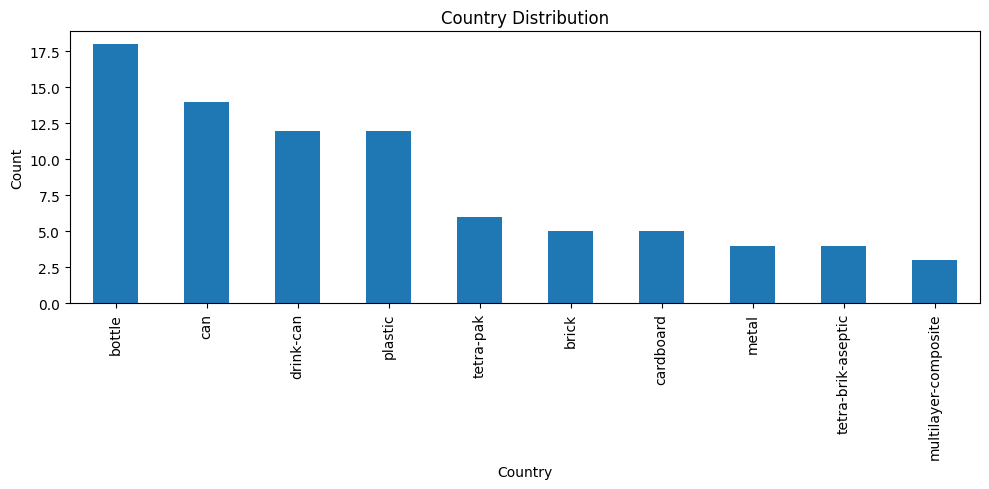

In [23]:
plt.figure(figsize=(10,5))

exploded_packaging.value_counts().head(10).plot(kind='bar')

plt.title("Country Distribution")
plt.ylabel("Count")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

In [24]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

# Extracting Nutriscore

In [25]:
df.nutriscore_grade.unique()

array(['c', 'e', 'unknown', 'd', 'b'], dtype=object)

In [26]:
df.nutriscore_grade.value_counts()

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [27]:
raw_nutriscore = df.nutriscore_grade.value_counts()
raw_nutriscore

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [28]:
raw_nutriscore = raw_nutriscore.drop("unknown")
raw_nutriscore

nutriscore_grade
e    144
b    102
c     83
d     40
Name: count, dtype: int64

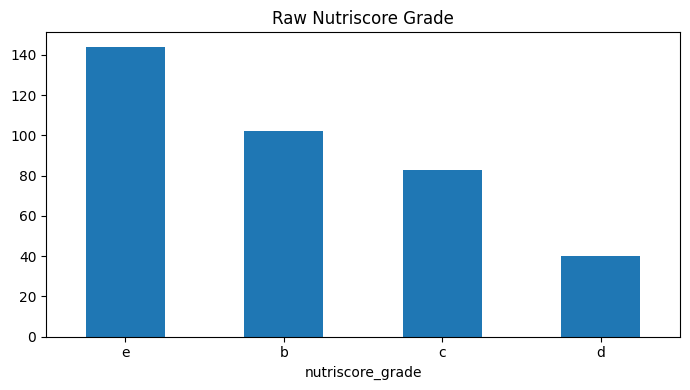

In [29]:
plt.figure(figsize=(7,4))

raw_nutriscore.plot(kind='bar')

plt.title("Raw Nutriscore Grade")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

# Extracting Nova Group

In [31]:
df.nova_group.unique()

array([ 4., nan,  1.,  3.])

In [32]:
df.nova_group.value_counts()
raw_nova = df.nova_group.value_counts()
raw_nova

nova_group
4.0    133
1.0     50
3.0      4
Name: count, dtype: int64

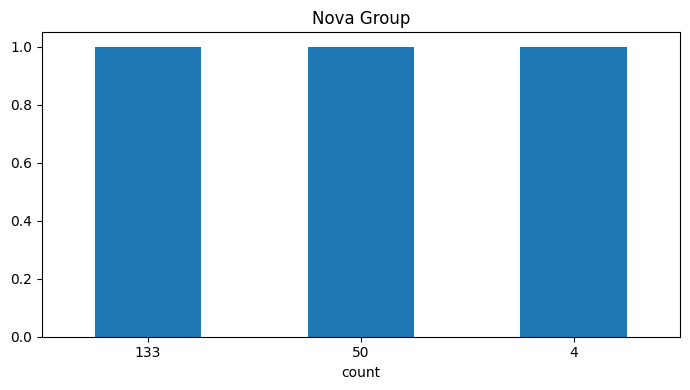

In [33]:
plt.figure(figsize=(7,4))

raw_nova.value_counts().plot(kind='bar')

plt.title("Nova Group")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

# Countries By Packaging

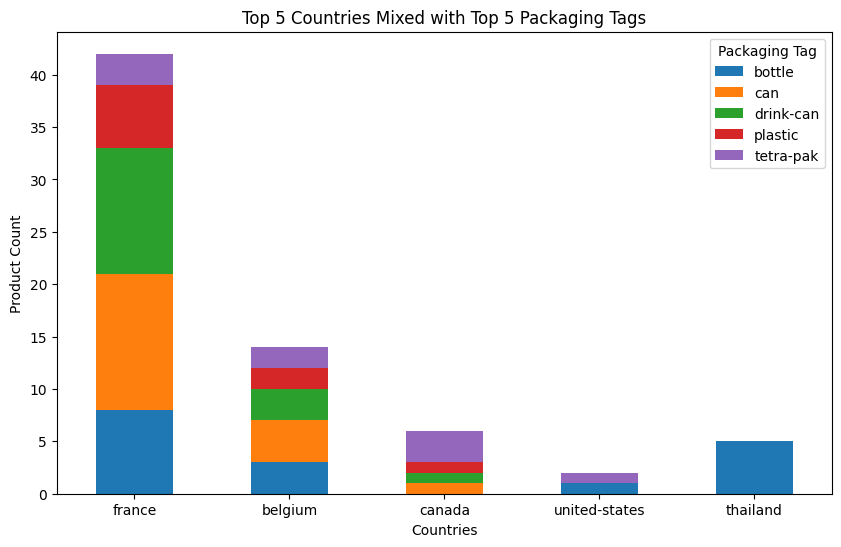

In [ ]:
df_cp = df[['countries_tags', 'packaging_tags']].copy()

df_cp['countries_tags'] = df_cp['countries_tags'].astype(str).str.split(',')
df_cp = df_cp.explode('countries_tags')
df_cp['countries_tags'] = df_cp['countries_tags'].str.strip()

df_cp['packaging_tags'] = df_cp['packaging_tags'].astype(str).str.split(',')
df_cp = df_cp.explode('packaging_tags')
df_cp['packaging_tags'] = df_cp['packaging_tags'].str.strip()

df_cp = df_cp[
    (~df_cp['countries_tags'].isin(['unknown', 'nan', ''])) & 
    (~df_cp['packaging_tags'].isin(['unknown', 'nan', '']))
]

top_countries = df_cp['countries_tags'].value_counts().head(5).index.drop_duplicates()
top_packaging = df_cp['packaging_tags'].value_counts().head(5).index.drop_duplicates()

df_cp_mixed = df_cp[
    (df_cp['countries_tags'].isin(top_countries)) & 
    (df_cp['packaging_tags'].isin(top_packaging))
]

cp_data = pd.crosstab(
    index=df_cp_mixed['countries_tags'],
    columns=df_cp_mixed['packaging_tags']
)

valid_countries = [c for c in top_countries if c in cp_data.index]
cp_data = cp_data.loc[valid_countries]

cp_data.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Top 5 Countries Mixed with Top 5 Packaging Tags')
plt.xlabel('Countries')
plt.ylabel('Product Count')
plt.legend(title='Packaging Tag')
plt.xticks(rotation=0)
plt.show()

# Countries By Nutri-Score

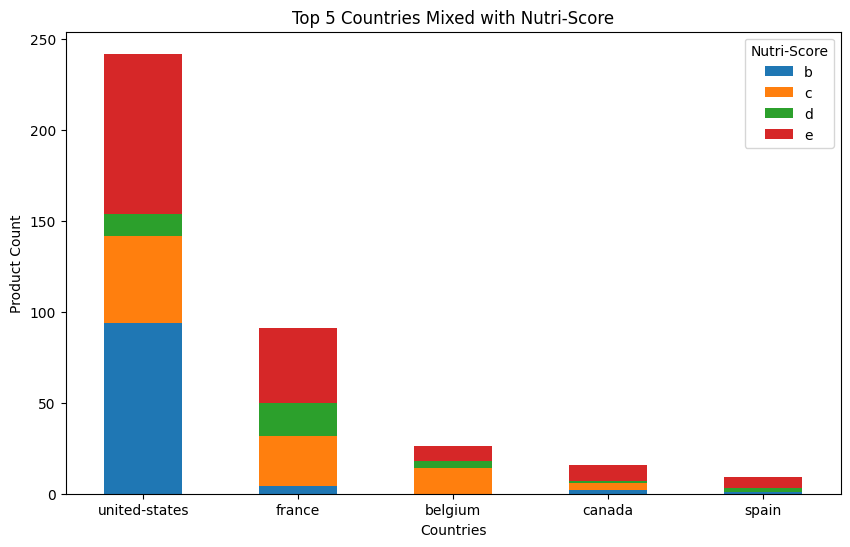

In [ ]:
df_cn = df[['countries_tags', 'nutriscore_grade']].copy()

df_cn['countries_tags'] = df_cn['countries_tags'].astype(str).str.split(',')
df_cn = df_cn.explode('countries_tags')
df_cn['countries_tags'] = df_cn['countries_tags'].str.strip()

df_cn = df_cn[
    (~df_cn['countries_tags'].isin(['unknown', 'nan', ''])) &
    (~df_cn['nutriscore_grade'].isin(['unknown', 'nan', '']))
]

top_countries = df_cn['countries_tags'].value_counts().head(5).index.drop_duplicates()
top_nutri = df_cn['nutriscore_grade'].value_counts().head(5).index.drop_duplicates()

df_cn_mixed = df_cn[
    (df_cn['countries_tags'].isin(top_countries)) &
    (df_cn['nutriscore_grade'].isin(top_nutri))
]

cn_data = pd.crosstab(
    index=df_cn_mixed['countries_tags'],
    columns=df_cn_mixed['nutriscore_grade']
)

valid_countries = [c for c in top_countries if c in cn_data.index]
cn_data = cn_data.loc[valid_countries]


cn_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Top 5 Countries Mixed with Nutri-Score')
plt.xlabel('Countries')
plt.ylabel('Product Count')
plt.legend(title='Nutri-Score')
plt.xticks(rotation=0)
plt.show()

# Countries By NOVA Group

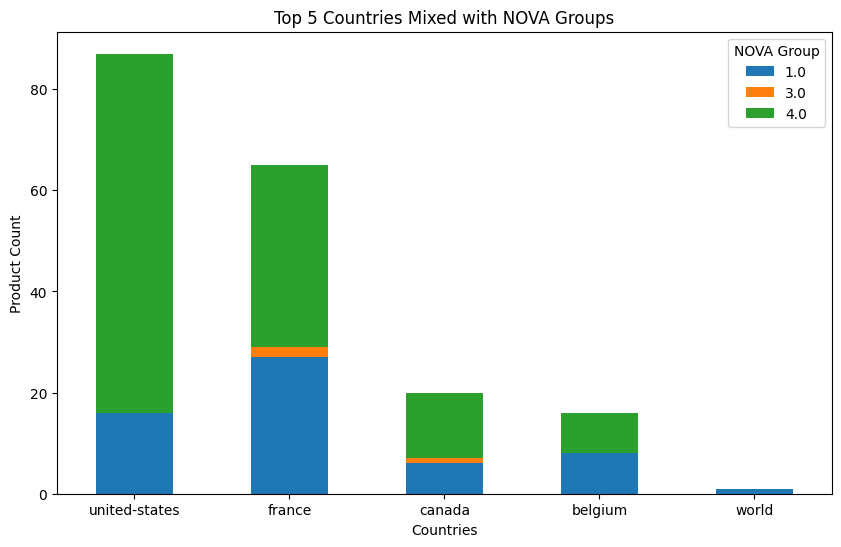

In [ ]:
df_cnova = df[['countries_tags', 'nova_group']].copy()

df_cnova['countries_tags'] = df_cnova['countries_tags'].astype(str).str.split(',')
df_cnova = df_cnova.explode('countries_tags')
df_cnova['countries_tags'] = df_cnova['countries_tags'].str.strip()

df_cnova = df_cnova[
    (~df_cnova['countries_tags'].isin(['unknown', 'nan', ''])) &
    (~df_cnova['nova_group'].isin(['unknown', 'nan', '']))
]

top_countries = df_cnova['countries_tags'].value_counts().head(5).index.drop_duplicates()
top_nova = df_cnova['nova_group'].value_counts().head(5).index.drop_duplicates()

df_cnova_mixed = df_cnova[
    (df_cnova['countries_tags'].isin(top_countries)) &
    (df_cnova['nova_group'].isin(top_nova))
]

cnova_data = pd.crosstab(
    index=df_cnova_mixed['countries_tags'],
    columns=df_cnova_mixed['nova_group']
)

valid_countries = [c for c in top_countries if c in cnova_data.index]
cnova_data = cnova_data.loc[valid_countries]

cnova_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Top 5 Countries Mixed with NOVA Groups')
plt.xlabel('Countries')
plt.ylabel('Product Count')
plt.legend(title='NOVA Group')
plt.xticks(rotation=0)
plt.show()

# Packaging By Nutri-Score

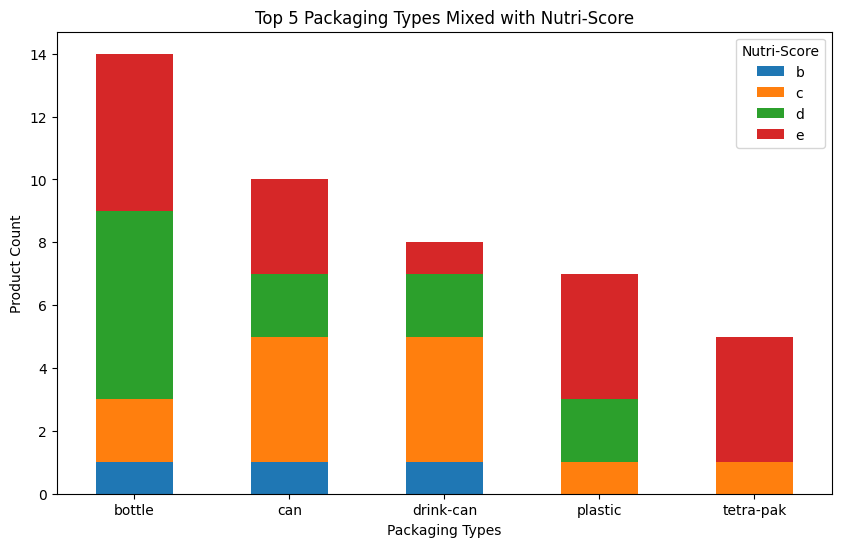

In [ ]:
df_pn = df[['packaging_tags', 'nutriscore_grade']].copy()

df_pn['packaging_tags'] = df_pn['packaging_tags'].astype(str).str.split(',')
df_pn = df_pn.explode('packaging_tags')
df_pn['packaging_tags'] = df_pn['packaging_tags'].str.strip()

df_pn = df_pn[
    (~df_pn['packaging_tags'].isin(['unknown', 'nan', ''])) &
    (~df_pn['nutriscore_grade'].isin(['unknown', 'nan', '']))
]

top_packaging = df_pn['packaging_tags'].value_counts().head(5).index.drop_duplicates()
top_nutri = df_pn['nutriscore_grade'].value_counts().head(5).index.drop_duplicates()

df_pn_mixed = df_pn[
    (df_pn['packaging_tags'].isin(top_packaging)) &
    (df_pn['nutriscore_grade'].isin(top_nutri))
]

pn_data = pd.crosstab(
    index=df_pn_mixed['packaging_tags'],
    columns=df_pn_mixed['nutriscore_grade']
)

valid_packaging = [p for p in top_packaging if p in pn_data.index]
pn_data = pn_data.loc[valid_packaging]

pn_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Top 5 Packaging Types Mixed with Nutri-Score')
plt.xlabel('Packaging Types')
plt.ylabel('Product Count')
plt.legend(title='Nutri-Score')
plt.xticks(rotation=0)
plt.show()

# Packaging by NOVA Group

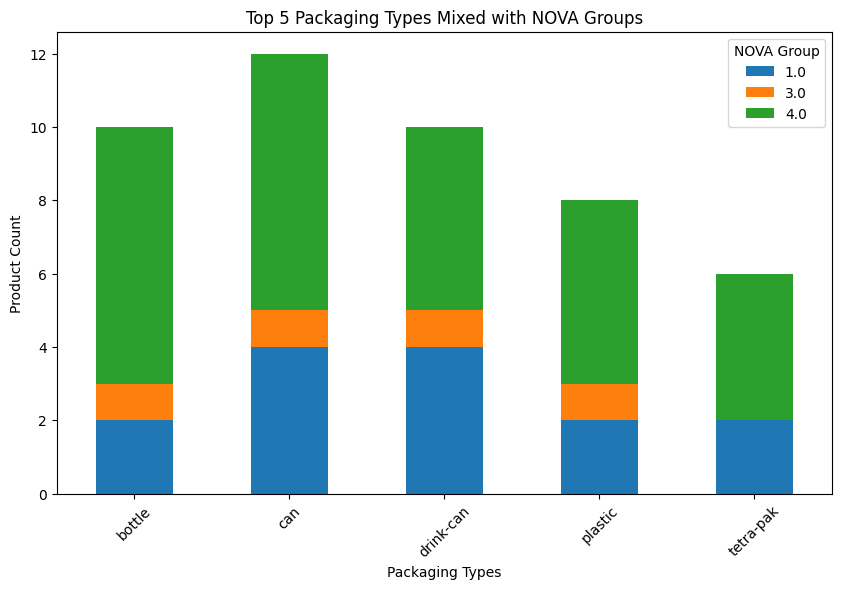

In [ ]:
df_pnova = df[['packaging_tags', 'nova_group']].copy()

df_pnova['packaging_tags'] = df_pnova['packaging_tags'].astype(str).str.split(',')
df_pnova = df_pnova.explode('packaging_tags')
df_pnova['packaging_tags'] = df_pnova['packaging_tags'].str.strip()

df_pnova = df_pnova[
    (~df_pnova['packaging_tags'].isin(['unknown', 'nan', ''])) &
    (~df_pnova['nova_group'].isin(['unknown', 'nan', '']))
]

top_packaging = df_pnova['packaging_tags'].value_counts().head(5).index.drop_duplicates()
top_nova = df_pnova['nova_group'].value_counts().head(5).index.drop_duplicates()

df_pnova_mixed = df_pnova[
    (df_pnova['packaging_tags'].isin(top_packaging)) &
    (df_pnova['nova_group'].isin(top_nova))
]

pnova_data = pd.crosstab(
    index=df_pnova_mixed['packaging_tags'],
    columns=df_pnova_mixed['nova_group']
)

valid_packaging = [p for p in top_packaging if p in pnova_data.index]
pnova_data = pnova_data.loc[valid_packaging]

pnova_data.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title('Top 5 Packaging Types Mixed with NOVA Groups')
plt.xlabel('Packaging Types')
plt.ylabel('Product Count')
plt.legend(title='NOVA Group')
plt.xticks(rotation=45)
plt.show()

# Multivarient Countries By Packaging By Nutriscore

In [ ]:
df_multi = df[['countries_tags', 'packaging_tags', 'nutriscore_grade']].copy()


df_multi['countries_tags'] = df_multi['countries_tags'].astype(str).str.split(',')
df_multi = df_multi.explode('countries_tags')
df_multi['countries_tags'] = df_multi['countries_tags'].str.strip()


df_multi['packaging_tags'] = df_multi['packaging_tags'].astype(str).str.split(',')
df_multi = df_multi.explode('packaging_tags')
df_multi['packaging_tags'] = df_multi['packaging_tags'].str.strip()


df_multi = df_multi[
    (~df_multi['countries_tags'].isin(['unknown', 'nan', ''])) &
    (~df_multi['packaging_tags'].isin(['unknown', 'nan', ''])) &
    (~df_multi['nutriscore_grade'].isin(['unknown', 'nan', '']))
]

top_countries = df_multi['countries_tags'].value_counts().head(5).index.drop_duplicates()
top_packaging = df_multi['packaging_tags'].value_counts().head(5).index.drop_duplicates()

df_multi = df_multi[
    (df_multi['countries_tags'].isin(top_countries)) &
    (df_multi['packaging_tags'].isin(top_packaging))
]

multi_data = (
    df_multi
    .groupby(['countries_tags',
              'packaging_tags',
              'nutriscore_grade'])
    .size()
    .reset_index(name='Product Count')
)

# 6. Display the result

print(multi_data)

   countries_tags packaging_tags nutriscore_grade  Product Count
0         belgium         bottle                c              2
1         belgium         bottle                e              1
2         belgium            can                c              2
3         belgium            can                e              2
4         belgium      drink-can                c              2
5         belgium      drink-can                e              1
6         belgium        plastic                c              1
7         belgium        plastic                e              1
8         belgium      tetra-pak                c              1
9         belgium      tetra-pak                e              1
10         canada        plastic                e              1
11         canada      tetra-pak                e              3
12         france         bottle                b              1
13         france         bottle                c              2
14         france        

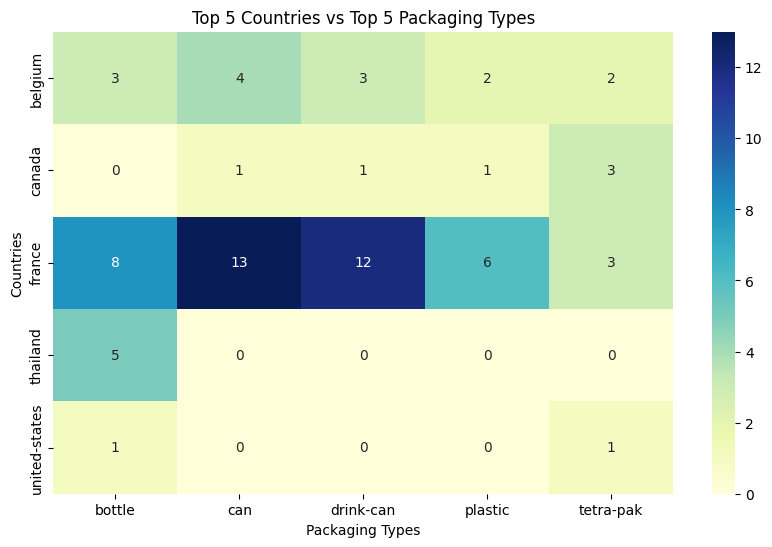

In [ ]:
df_multi = df[['countries_tags', 'packaging_tags']].copy()


df_multi['countries_tags'] = df_multi['countries_tags'].astype(str).str.split(',')
df_multi = df_multi.explode('countries_tags')
df_multi['countries_tags'] = df_multi['countries_tags'].str.strip()


df_multi['packaging_tags'] = df_multi['packaging_tags'].astype(str).str.split(',')
df_multi = df_multi.explode('packaging_tags')
df_multi['packaging_tags'] = df_multi['packaging_tags'].str.strip()


df_multi = df_multi[
    (~df_multi['countries_tags'].isin(['unknown','nan',''])) &
    (~df_multi['packaging_tags'].isin(['unknown','nan','']))
]


top_countries = df_multi['countries_tags'].value_counts().head(5).index
top_packaging = df_multi['packaging_tags'].value_counts().head(5).index

df_multi = df_multi[
    (df_multi['countries_tags'].isin(top_countries)) &
    (df_multi['packaging_tags'].isin(top_packaging))
]


heatmap_data = pd.crosstab(
    df_multi['countries_tags'],
    df_multi['packaging_tags']
)


plt.figure(figsize=(10,6))

sb.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title("Top 5 Countries vs Top 5 Packaging Types")
plt.xlabel("Packaging Types")
plt.ylabel("Countries")
plt.show()

# Country wise observation 

In [42]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

In [51]:
df[df['countries_tags'].str.contains("france")]

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,c,4.0,unknown,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,unknown,unknown,unknown,e,4.0,unknown,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
5,0025000061516,100% apple juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,e,NaN,unknown,"CONTAINS PURE FILTERED WATER, CONCENTRATED APP...",NaN,NaN
9,0059600060594,Minute Maid Orange,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,5449000340023,Jus d'orange Minute Maid,Minute maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,e,NaN,unknown,Jus d'orange à base de concentré (55%) ; eau ;...,NaN,NaN
655,54032491,unknown,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
660,5449000341112,minute maid orange nectar vit c,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
666,5449000340108,pack 6x 20cl minute maid orange,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
